In [9]:
import pandas as pd
import geopandas as gpd
import re
import numpy as np
pd.set_option('display.max_columns', None)

In [2]:
month_start = {"January": pd.to_datetime("2026-01-01"), "February": pd.to_datetime("2026-02-01"), 
               "March": pd.to_datetime("2026-03-01"), "April": pd.to_datetime("2026-04-01"), 
               "May": pd.to_datetime("2026-05-01"), "June": pd.to_datetime("2026-06-01"), 
               "July": pd.to_datetime("2026-07-01"), "August": pd.to_datetime("2026-08-01"), 
               "September": pd.to_datetime("2026-09-01"), "October": pd.to_datetime("2026-10-01"),
              "November": pd.to_datetime("2026-11-01"), "December": pd.to_datetime("2026-12-01")}

month_end = {"January": pd.to_datetime("2026-01-31 23:59:59.999999"), "February": pd.to_datetime("2026-02-28 23:59:59.999999"), 
               "March": pd.to_datetime("2026-03-31 23:59:59.999999"), "April": pd.to_datetime("2026-04-30 23:59:59.999999"), 
               "May": pd.to_datetime("2026-05-31 23:59:59.999999"), "June": pd.to_datetime("2026-06-30 23:59:59.999999"), 
               "July": pd.to_datetime("2026-07-31 23:59:59.999999"), "August": pd.to_datetime("2026-08-31 23:59:59.999999"), 
               "September": pd.to_datetime("2026-09-30 23:59:59.999999"), "October": pd.to_datetime("2026-10-31 23:59:59.999999"),
              "November": pd.to_datetime("2026-11-30 23:59:59.999999"), "December": pd.to_datetime("2026-12-31 23:59:59.999999")}

In [24]:
def split_date(date):
    if date != date:
        return []
    elif date == "Non-flowering":
        return []
    elif date == "Seasonal bloomer":
        return []
    elif date == "N/a":
        return []
    else:
        pieces = re.split(r'\s+to\s+', date)
        normalized_pieces = [re.sub(r"\s+", "", piece) for piece in pieces]
        return normalized_pieces



In [19]:
def date_list(months: list):
    if len(months) > 1:
        rng = pd.date_range(start=month_start[months[0]],
                              end=month_end[months[1]], freq='1D')
        return rng
    elif len(months) == 1:
        rng = pd.date_range(start=month_start[months[0]],
                              end=month_end[months[0]], freq='1D')
        return rng
    else:
        return np.nan

In [11]:
phenos = gpd.read_file("/Users/prince/philly-tree-mapper/data/raw/philly_species_pheno.geojson")
phenos = phenos.drop(columns=["objectid", "Morphology/Physiology | Active Growth Period", "geometry"])

In [23]:
phenos["Bloom Time"].value_counts(dropna=False)

Bloom Time
N/a                    77
April                  52
April to May           39
March to April         30
Non-flowering          23
May to June            21
May                    13
June                   13
March                   9
June to July            5
July to August          3
February                1
April to June           1
October to December     1
July to September       1
August to September     1
May to July             1
Seasonal bloomer        1
June to October         1
February to April       1
Name: count, dtype: int64

In [25]:
phenos["bloom_range"] = phenos["Bloom Time"].apply(lambda d: date_list(split_date(d)))

In [38]:
phenos[101:151]

,tree_name,scientific_name,common_name,Genus,Species,plant_code,Morphology/Physiology | Fall Conspicuous,Morphology/Physiology | Flower Color,Morphology/Physiology | Flower Conspicuous,Morphology/Physiology | Foliage Color,Morphology/Physiology | Foliage Porosity Summer,Morphology/Physiology | Foliage Porosity Winter,Morphology/Physiology | Fruit/Seed Color,Morphology/Physiology | Fruit/Seed Conspicuous,Morphology/Physiology | Leaf Retention,Reproduction | Bloom Period,Reproduction | Fruit/Seed Abundance,Reproduction | Fruit/Seed Period Begin,Reproduction | Fruit/Seed Period End,Suitability/Use | Palatable Human,Scientific Name,Bloom Time,Bloom Description,Flower,Leaf,Status,Detail URL,bloom_range
101,Malus pumila - apple,malus pumila,apple,Malus,pumila,MALUS,Yes,Purple,Yes,Green,Dense,Porous,Red,Yes,No,Mid Spring,Medium,Summer,Fall,No,malus pumila,April,White,Showy,N/a,"fuzzy (sci=0.73, com=1.00)",https://www.missouribotanicalgarden.org/PlantF...,"DatetimeIndex(['2026-04-01', '2026-04-02', '20..."
102,Maclura pomifera - osage orange,maclura pomifera,osage orange,Maclura,pomifera,MAPO,No,Green,No,Green,Dense,Porous,Orange,Yes,No,Late Spring,Medium,Summer,Fall,No,maclura pomifera,June,Green,Insignificant,N/a,matched,https://www.missouribotanicalgarden.org/PlantF...,"DatetimeIndex(['2026-06-01', '2026-06-02', '20..."
103,Maclura pomifera - white shield osage orange,maclura pomifera,white shield osage orange,Maclura,pomifera,MAPO,No,Green,No,Green,Dense,Porous,Orange,Yes,No,Late Spring,Medium,Summer,Fall,No,maclura pomifera,June,Green,Insignificant,N/a,matched,https://www.missouribotanicalgarden.org/PlantF...,"DatetimeIndex(['2026-06-01', '2026-06-02', '20..."
104,Magnolia stellata - star magnolia,magnolia stellata,star magnolia,Magnolia,stellata,MAST6,No,White,Yes,Green,Moderate,Porous,Brown,No,No,Mid Spring,Medium,Spring,Summer,No,magnolia stellata,March,White,"Showy, Fragrant",N/a,matched,https://www.missouribotanicalgarden.org/PlantF...,"DatetimeIndex(['2026-03-01', '2026-03-02', '20..."
105,Magnolia tripetala - umbrella magnolia,magnolia tripetala,umbrella magnolia,Magnolia,tripetala,MATR,No,White,Yes,Green,Porous,Porous,Red,Yes,No,Spring,Medium,Summer,Summer,No,magnolia tripetala,May,White,Showy,N/a,matched,https://www.missouribotanicalgarden.org/PlantF...,"DatetimeIndex(['2026-05-01', '2026-05-02', '20..."
106,Magnolia virginiana - sweetbay magnolia,magnolia virginiana,sweetbay magnolia,Magnolia,virginiana,MAVI2,No,White,Yes,Dark Green,Moderate,Moderate,Black,Yes,Yes,Summer,Medium,Summer,Winter,No,magnolia virginiana,May to June,White,"Showy, Fragrant",N/a,matched,https://www.missouribotanicalgarden.org/PlantF...,"DatetimeIndex(['2026-05-01', '2026-05-02', '20..."
107,Metasequoia glyptostroboides - dawn redwood,metasequoia glyptostroboides,dawn redwood,Metasequoia,glyptostroboides,MEGL8,Yes,Yellow,No,Green,Dense,Porous,Brown,No,No,Spring,Low,Summer,Summer,No,metasequoia glyptostroboides,Non-flowering,Non-flowering,N/a,N/a,matched,https://www.missouribotanicalgarden.org/PlantF...,NaN
108,Morus alba - white mulberry,morus alba,white mulberry,Morus,alba,MOAL,No,Green,No,Green,Moderate,Porous,Purple,Yes,No,Early Spring,High,Spring,Summer,No,morus alba,March to April,Yellowish-green,Insignificant,N/a,matched,https://www.missouribotanicalgarden.org/PlantF...,"DatetimeIndex(['2026-03-01', '2026-03-02', '20..."
109,Morus rubra - red mulberry,morus rubra,red mulberry,Morus,rubra,MORU2,No,Green,No,Green,Moderate,Porous,Purple,Yes,No,Early Spring,High,Spring,Summer,Yes,morus rubra,March to April,Green,Insignificant,N/a,matched,https://www.missouribotanicalgarden.org/PlantF...,"DatetimeIndex(['2026-03-01', '2026-03-02', '20..."
110,Nyssa sylvatica - blackgum,nyssa sylvatica,blackgum,Nyssa,sylvatica,NYSY,Yes,Green,No,Green,Dense,Porous,Blue,No,No,Late Spring,Medium,Summer,Fall,No,nyssa sylvatica,May to June,Greenish white,Insignificant,Good Fall,matched,https://www.missouribotanicalgarden.org/PlantF...,"DatetimeIndex(['2026-05-01', '20

In [ ]:
usda_mobot_blooms = phenos.loc[(~phenos["Reproduction | Bloom Period"].isna()) & (~phenos["bloom_range"].isna())]

In [45]:
agg_bloom_times = usda_mobot_blooms.groupby("Reproduction | Bloom Period", as_index=False)["Bloom Time"].value_counts()

In [39]:
usda_hit_mobot_miss = phenos.loc[(~phenos["plant_code"].isna()) & ((phenos["Status"] == "no exact match") | (phenos["Status"] == "no results container"))]

In [44]:
usda_hit_mobot_miss

,tree_name,scientific_name,common_name,Genus,Species,plant_code,Morphology/Physiology | Fall Conspicuous,Morphology/Physiology | Flower Color,Morphology/Physiology | Flower Conspicuous,Morphology/Physiology | Foliage Color,Morphology/Physiology | Foliage Porosity Summer,Morphology/Physiology | Foliage Porosity Winter,Morphology/Physiology | Fruit/Seed Color,Morphology/Physiology | Fruit/Seed Conspicuous,Morphology/Physiology | Leaf Retention,Reproduction | Bloom Period,Reproduction | Fruit/Seed Abundance,Reproduction | Fruit/Seed Period Begin,Reproduction | Fruit/Seed Period End,Suitability/Use | Palatable Human,Scientific Name,Bloom Time,Bloom Description,Flower,Leaf,Status,Detail URL,bloom_range
2,Acer ginnala - amur maple,acer ginnala,amur maple,Acer,ginnala,ACGI,Yes,White,No,Green,Dense,Moderate,Brown,Yes,No,Mid Spring,High,Summer,Fall,No,acer ginnala,N/a,N/a,N/a,N/a,no results container,NaN,NaN
4,Acer nigrum - black maple,acer nigrum,black maple,Acer,nigrum,ACNI5,Yes,Yellow,No,Green,Dense,Porous,Brown,No,No,Late Spring,Medium,Summer,Fall,Yes,acer nigrum,N/a,N/a,N/a,N/a,no results container,NaN,NaN
5,Acer pensyvanicum - striped maple,acer pensyvanicum,striped maple,Acer,pensyvanicum,ACPE,Yes,Yellow,No,Green,Moderate,Porous,Brown,No,No,Late Spring,Medium,Summer,Fall,No,acer pensyvanicum,N/a,N/a,N/a,N/a,no results container,NaN,NaN
22,Aesculus octandra - yellow buckeye,aesculus octandra,yellow buckeye,Aesculus,octandra,AEFL,Yes,Yellow,Yes,Green,Dense,Porous,Brown,Yes,No,Late Spring,Medium,Summer,Fall,No,aesculus octandra,N/a,N/a,N/a,N/a,no results container,NaN,NaN
41,Casuarina equisetifolia - australian pine,casuarina equisetifolia,australian pine,Casuarina,equisetifolia,CAEQ,No,Red,No,Green,Dense,Dense,Brown,No,Yes,Mid Spring,High,Summer,Fall,No,casuarina equisetifolia,N/a,N/a,N/a,N/a,no results container,NaN,NaN
43,Carya illinoensis - pecan,carya illinoensis,pecan,Carya,illinoensis,CAIL2,No,Yellow,No,Yellow-Green,Dense,Porous,Brown,Yes,No,Early Spring,High,Summer,Fall,Yes,carya illinoensis,N/a,N/a,N/a,N/a,no results container,NaN,NaN
47,Castanea pumila - allegheny chinkapin,castanea pumila,allegheny chinkapin,Castanea,pumila,CAPU9,No,Yellow,No,Green,Dense,Porous,Brown,Yes,No,Spring,Low,Summer,Fall,Yes,castanea pumila,N/a,N/a,N/a,N/a,no results container,NaN,NaN
63,Crataegus marshallii - parsley hawthorn,crataegus marshallii,parsley hawthorn,Crataegus,marshallii,CRMA5,Yes,White,Yes,Green,Moderate,Porous,Red,Yes,No,Mid Spring,Medium,Summer,Fall,Yes,crataegus marshallii,N/a,N/a,N/a,N/a,no results container,NaN,NaN
64,Crataegus monogyna - english hawthorn,crataegus monogyna,english hawthorn,Crataegus,monogyna,CRMO3,Yes,Purple,Yes,Dark Green,Dense,Moderate,Red,Yes,No,Mid Spring,High,Summer,Fall,No,crataegus monogyna,N/a,N/a,N/a,N/a,no results container,NaN,NaN
76,Fraxinus nigra - black ash,fraxinus nigra,black ash,Fraxinus,nigra,FRNI,No,White,No,Green,Dense,Porous,Brown,No,No,Early Spring,Low,Summer,Summer,No,fraxinus nigra,N/a,N/a,N/a,N/a,no results container,NaN,NaN


Getting into claude code blocks to transform USDA bloom ranges to actual months based on MOBOT ranges

In [48]:
MONTHS = {m: i for i, m in enumerate(
    ['January','February','March','April','May','June',
     'July','August','September','October','November','December'], start=1)}
MONTH_ABBR = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']

def parse_bloom_time(s):
    if pd.isna(s):
        return []
    parts = [p.strip() for p in s.split(' to ')]
    months = [MONTHS[p] for p in parts if p in MONTHS]
    if len(months) == 1:
        return months
    if len(months) == 2:
        a, b = months
        return list(range(a, b + 1)) if a <= b else list(range(a, 13)) + list(range(1, b + 1))
    return []

# Explode agg_bloom_times into one row per (category, month) with weight
records = []
for _, r in agg_bloom_times.iterrows():
    cat = r['Reproduction | Bloom Period']
    cnt = r['count']
    for m in parse_bloom_time(r['Bloom Time']):
        records.append({'category': cat, 'month': m, 'weight': cnt})

hist_df = (pd.DataFrame(records)
           .groupby(['category', 'month'], as_index=False)['weight'].sum())

# Fill missing months with 0 so every facet shows the full Jan–Dec axis
all_combos = pd.MultiIndex.from_product(
    [hist_df['category'].unique(), range(1, 13)],
    names=['category', 'month']).to_frame(index=False)
hist_df = all_combos.merge(hist_df, on=['category', 'month'], how='left').fillna({'weight': 0})
hist_df['month_label'] = hist_df['month'].map(lambda m: MONTH_ABBR[m-1])

# Order facets by typical seasonal progression
category_order = ['Late Winter', 'Early Spring', 'Mid Spring', 'Late Spring', 'Spring',
                  'Early Summer', 'Mid Summer', 'Late Summer', 'Summer', 'Fall']


def category_month_range(df, category_col, time_col, count_col,
                         lo=0.10, hi=0.90, min_n=5):
    """Return DataFrame with (start_month, end_month) per USDA category,
    derived from the central (hi - lo) mass of the weighted month histogram."""
    rows = []
    for cat, g in df.groupby(category_col):
        mass = np.zeros(13)  # index 1..12; index 0 unused
        for _, r in g.iterrows():
            for m in parse_bloom_time(r[time_col]):
                mass[m] += r[count_col]
        n = mass.sum()
        if n < min_n:
            rows.append({'category': cat, 'n': int(n),
                         'start_month': None, 'end_month': None,
                         'note': 'insufficient data — use prior'})
            continue
        cdf = np.cumsum(mass[1:]) / n
        # smallest month whose cumulative mass first exceeds lo
        start = int(np.argmax(cdf >= lo) + 1)
        # smallest month whose cumulative mass reaches hi (inclusive)
        end   = int(np.argmax(cdf >= hi) + 1)
        rows.append({'category': cat, 'n': int(n),
                     'start_month': start, 'end_month': end, 'note': ''})
    return pd.DataFrame(rows).sort_values('start_month', na_position='last')

ranges = category_month_range(agg_bloom_times,
                              'Reproduction | Bloom Period',
                              'Bloom Time', 'count')
print(ranges)


       category   n  start_month  end_month                           note
0  Early Spring  56          3.0        5.0                               
6    Mid Spring  96          3.0        5.0                               
3   Late Spring  43          4.0        6.0                               
8        Spring  13          4.0        6.0                               
1  Early Summer  13          5.0        6.0                               
9        Summer   5          5.0        9.0                               
2          Fall   3          NaN        NaN  insufficient data — use prior
4   Late Summer   4          NaN        NaN  insufficient data — use prior
5   Late Winter   2          NaN        NaN  insufficient data — use prior
7    Mid Summer   2          NaN        NaN  insufficient data — use prior


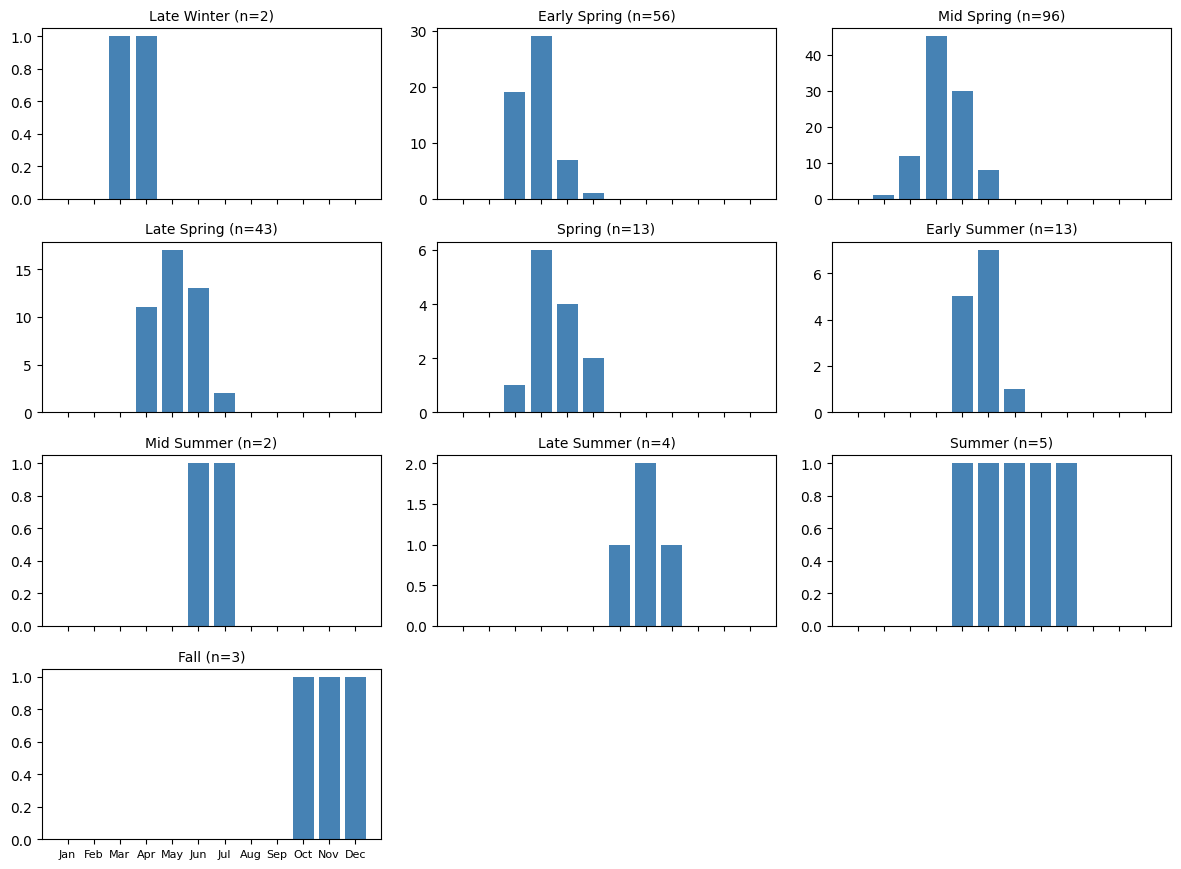

In [50]:
import matplotlib.pyplot as plt

categories = [c for c in category_order if c in hist_df['category'].unique()]
n = len(categories)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.2 * nrows), sharex=True)
for ax, cat in zip(axes.flat, categories):
    d = hist_df[hist_df['category'] == cat].sort_values('month')
    ax.bar(d['month'], d['weight'], color='steelblue')
    ax.set_title(f'{cat} (n={int(d["weight"].sum())})', fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=8)
for ax in axes.flat[n:]:
    ax.axis('off')
fig.tight_layout()
plt.show()

Back to my shit

In [54]:
bloom_dict = {"Early Spring": "March to May", "Late Spring": "April to June",
              "Mid Spring": "March to June", "Spring": "March to June"}

In [56]:
usda_hit_mobot_miss["Bloom Time"] = usda_hit_mobot_miss["Reproduction | Bloom Period"].map(bloom_dict)

In [57]:
usda_hit_mobot_miss

,tree_name,scientific_name,common_name,Genus,Species,plant_code,Morphology/Physiology | Fall Conspicuous,Morphology/Physiology | Flower Color,Morphology/Physiology | Flower Conspicuous,Morphology/Physiology | Foliage Color,Morphology/Physiology | Foliage Porosity Summer,Morphology/Physiology | Foliage Porosity Winter,Morphology/Physiology | Fruit/Seed Color,Morphology/Physiology | Fruit/Seed Conspicuous,Morphology/Physiology | Leaf Retention,Reproduction | Bloom Period,Reproduction | Fruit/Seed Abundance,Reproduction | Fruit/Seed Period Begin,Reproduction | Fruit/Seed Period End,Suitability/Use | Palatable Human,Scientific Name,Bloom Time,Bloom Description,Flower,Leaf,Status,Detail URL,bloom_range
2,Acer ginnala - amur maple,acer ginnala,amur maple,Acer,ginnala,ACGI,Yes,White,No,Green,Dense,Moderate,Brown,Yes,No,Mid Spring,High,Summer,Fall,No,acer ginnala,March to June,N/a,N/a,N/a,no results container,NaN,NaN
4,Acer nigrum - black maple,acer nigrum,black maple,Acer,nigrum,ACNI5,Yes,Yellow,No,Green,Dense,Porous,Brown,No,No,Late Spring,Medium,Summer,Fall,Yes,acer nigrum,April to June,N/a,N/a,N/a,no results container,NaN,NaN
5,Acer pensyvanicum - striped maple,acer pensyvanicum,striped maple,Acer,pensyvanicum,ACPE,Yes,Yellow,No,Green,Moderate,Porous,Brown,No,No,Late Spring,Medium,Summer,Fall,No,acer pensyvanicum,April to June,N/a,N/a,N/a,no results container,NaN,NaN
22,Aesculus octandra - yellow buckeye,aesculus octandra,yellow buckeye,Aesculus,octandra,AEFL,Yes,Yellow,Yes,Green,Dense,Porous,Brown,Yes,No,Late Spring,Medium,Summer,Fall,No,aesculus octandra,April to June,N/a,N/a,N/a,no results container,NaN,NaN
41,Casuarina equisetifolia - australian pine,casuarina equisetifolia,australian pine,Casuarina,equisetifolia,CAEQ,No,Red,No,Green,Dense,Dense,Brown,No,Yes,Mid Spring,High,Summer,Fall,No,casuarina equisetifolia,March to June,N/a,N/a,N/a,no results container,NaN,NaN
43,Carya illinoensis - pecan,carya illinoensis,pecan,Carya,illinoensis,CAIL2,No,Yellow,No,Yellow-Green,Dense,Porous,Brown,Yes,No,Early Spring,High,Summer,Fall,Yes,carya illinoensis,March to May,N/a,N/a,N/a,no results container,NaN,NaN
47,Castanea pumila - allegheny chinkapin,castanea pumila,allegheny chinkapin,Castanea,pumila,CAPU9,No,Yellow,No,Green,Dense,Porous,Brown,Yes,No,Spring,Low,Summer,Fall,Yes,castanea pumila,March to June,N/a,N/a,N/a,no results container,NaN,NaN
63,Crataegus marshallii - parsley hawthorn,crataegus marshallii,parsley hawthorn,Crataegus,marshallii,CRMA5,Yes,White,Yes,Green,Moderate,Porous,Red,Yes,No,Mid Spring,Medium,Summer,Fall,Yes,crataegus marshallii,March to June,N/a,N/a,N/a,no results container,NaN,NaN
64,Crataegus monogyna - english hawthorn,crataegus monogyna,english hawthorn,Crataegus,monogyna,CRMO3,Yes,Purple,Yes,Dark Green,Dense,Moderate,Red,Yes,No,Mid Spring,High,Summer,Fall,No,crataegus monogyna,March to June,N/a,N/a,N/a,no results container,NaN,NaN
76,Fraxinus nigra - black ash,fraxinus nigra,black ash,Fraxinus,nigra,FRNI,No,White,No,Green,Dense,Porous,Brown,No,No,Early Spring,Low,Summer,Summer,No,fraxinus nigra,March to May,N/a,N/a,N/a,no results container,NaN,NaN


In [58]:
usda_hit_mobot_miss["bloom_range"] = usda_hit_mobot_miss["Bloom Time"].apply(lambda d: date_list(split_date(d)))

In [59]:
usda_hit_mobot_miss

,tree_name,scientific_name,common_name,Genus,Species,plant_code,Morphology/Physiology | Fall Conspicuous,Morphology/Physiology | Flower Color,Morphology/Physiology | Flower Conspicuous,Morphology/Physiology | Foliage Color,Morphology/Physiology | Foliage Porosity Summer,Morphology/Physiology | Foliage Porosity Winter,Morphology/Physiology | Fruit/Seed Color,Morphology/Physiology | Fruit/Seed Conspicuous,Morphology/Physiology | Leaf Retention,Reproduction | Bloom Period,Reproduction | Fruit/Seed Abundance,Reproduction | Fruit/Seed Period Begin,Reproduction | Fruit/Seed Period End,Suitability/Use | Palatable Human,Scientific Name,Bloom Time,Bloom Description,Flower,Leaf,Status,Detail URL,bloom_range
2,Acer ginnala - amur maple,acer ginnala,amur maple,Acer,ginnala,ACGI,Yes,White,No,Green,Dense,Moderate,Brown,Yes,No,Mid Spring,High,Summer,Fall,No,acer ginnala,March to June,N/a,N/a,N/a,no results container,NaN,"DatetimeIndex(['2026-03-01', '2026-03-02', '20..."
4,Acer nigrum - black maple,acer nigrum,black maple,Acer,nigrum,ACNI5,Yes,Yellow,No,Green,Dense,Porous,Brown,No,No,Late Spring,Medium,Summer,Fall,Yes,acer nigrum,April to June,N/a,N/a,N/a,no results container,NaN,"DatetimeIndex(['2026-04-01', '2026-04-02', '20..."
5,Acer pensyvanicum - striped maple,acer pensyvanicum,striped maple,Acer,pensyvanicum,ACPE,Yes,Yellow,No,Green,Moderate,Porous,Brown,No,No,Late Spring,Medium,Summer,Fall,No,acer pensyvanicum,April to June,N/a,N/a,N/a,no results container,NaN,"DatetimeIndex(['2026-04-01', '2026-04-02', '20..."
22,Aesculus octandra - yellow buckeye,aesculus octandra,yellow buckeye,Aesculus,octandra,AEFL,Yes,Yellow,Yes,Green,Dense,Porous,Brown,Yes,No,Late Spring,Medium,Summer,Fall,No,aesculus octandra,April to June,N/a,N/a,N/a,no results container,NaN,"DatetimeIndex(['2026-04-01', '2026-04-02', '20..."
41,Casuarina equisetifolia - australian pine,casuarina equisetifolia,australian pine,Casuarina,equisetifolia,CAEQ,No,Red,No,Green,Dense,Dense,Brown,No,Yes,Mid Spring,High,Summer,Fall,No,casuarina equisetifolia,March to June,N/a,N/a,N/a,no results container,NaN,"DatetimeIndex(['2026-03-01', '2026-03-02', '20..."
43,Carya illinoensis - pecan,carya illinoensis,pecan,Carya,illinoensis,CAIL2,No,Yellow,No,Yellow-Green,Dense,Porous,Brown,Yes,No,Early Spring,High,Summer,Fall,Yes,carya illinoensis,March to May,N/a,N/a,N/a,no results container,NaN,"DatetimeIndex(['2026-03-01', '2026-03-02', '20..."
47,Castanea pumila - allegheny chinkapin,castanea pumila,allegheny chinkapin,Castanea,pumila,CAPU9,No,Yellow,No,Green,Dense,Porous,Brown,Yes,No,Spring,Low,Summer,Fall,Yes,castanea pumila,March to June,N/a,N/a,N/a,no results container,NaN,"DatetimeIndex(['2026-03-01', '2026-03-02', '20..."
63,Crataegus marshallii - parsley hawthorn,crataegus marshallii,parsley hawthorn,Crataegus,marshallii,CRMA5,Yes,White,Yes,Green,Moderate,Porous,Red,Yes,No,Mid Spring,Medium,Summer,Fall,Yes,crataegus marshallii,March to June,N/a,N/a,N/a,no results container,NaN,"DatetimeIndex(['2026-03-01', '2026-03-02', '20..."
64,Crataegus monogyna - english hawthorn,crataegus monogyna,english hawthorn,Crataegus,monogyna,CRMO3,Yes,Purple,Yes,Dark Green,Dense,Moderate,Red,Yes,No,Mid Spring,High,Summer,Fall,No,crataegus monogyna,March to June,N/a,N/a,N/a,no results container,NaN,"DatetimeIndex(['2026-03-01', '2026-03-02', '20..."
76,Fraxinus nigra - black ash,fraxinus nigra,black ash,Fraxinus,nigra,FRNI,No,White,No,Green,Dense,Porous,Brown,No,No,Early Spring,Low,Summer,Summer,No,fraxinus nigra,March to May,N/a,N/a,N/a,no results container,NaN,"DatetimeIndex(['2026-03-01', '2026-03-02', '20..."


In [66]:
for idx in usda_hit_mobot_miss.index:
    phenos.at[idx, "bloom_range"] = usda_hit_mobot_miss.loc[idx, "bloom_range"]

Now I have bloom ranges for everything. USDA bloom ranges are just for when pollen is shed and stigmas are receptive

In [68]:
phenos.to_csv("/Users/prince/philly-tree-mapper/data/processed/philly_species_pheno_deaggregated.csv")